# Data Pipeline & PyTorch DataLoaders
## Production-Ready Data Loading with Augmentations

This notebook creates:
- Custom PyTorch Dataset class
- Comprehensive augmentation pipeline
- DataLoaders with optimal configuration
- Batch visualization and profiling

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import json
import logging
import time
from collections import defaultdict

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f'Using device: {device}')

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

INFO:__main__:Using device: cpu


PyTorch version: 2.12.0+cpu
CUDA available: False


## 1. Define Custom Dataset Class

In [2]:
class CropDiseaseDataset(Dataset):
    """Custom Dataset for Crop Disease Detection"""
    
    def __init__(self, data_dir, metadata_path, split='train', transforms=None):
        """
        Args:
            data_dir: Path to dataset directory (train/val/test folders)
            metadata_path: Path to dataset_metadata.json
            split: 'train', 'val', or 'test'
            transforms: torchvision transforms to apply
        """
        self.data_dir = Path(data_dir) / split
        self.transforms = transforms
        self.split = split
        
        # Load metadata
        with open(metadata_path, 'r') as f:
            self.metadata = json.load(f)
        
        self.class_to_idx = self.metadata['class_to_idx']
        self.idx_to_class = {v: k for k, v in self.class_to_idx.items()}
        
        # Build image list
        self.image_paths = []
        self.labels = []
        
        for class_folder in self.data_dir.iterdir():
            if class_folder.is_dir() and class_folder.name in self.class_to_idx:
                class_id = self.class_to_idx[class_folder.name]
                
                # Find all image files
                images = (list(class_folder.glob('*.jpg')) + 
                         list(class_folder.glob('*.jpeg')) +
                         list(class_folder.glob('*.png')) +
                         list(class_folder.glob('*.JPG')))
                
                for img_path in images:
                    self.image_paths.append(img_path)
                    self.labels.append(class_id)
        
        logger.info(f'Loaded {len(self)} images for {split} split')
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        # Load image
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            logger.warning(f'Error loading {img_path}: {e}')
            # Return black image as fallback
            image = Image.new('RGB', (256, 256), color=(0, 0, 0))
        
        # Apply transforms
        if self.transforms:
            image = self.transforms(image)
        
        return image, label
    
    def get_class_distribution(self):
        """Get class distribution for weighted sampling"""
        unique, counts = np.unique(self.labels, return_counts=True)
        return dict(zip(unique, counts))

## 2. Define Augmentation Pipelines

In [3]:
def get_train_transforms(img_size=224):
    """Strong augmentation for training"""
    return transforms.Compose([
        transforms.Resize((256, 256), 
                           interpolation=transforms.InterpolationMode.LANCZOS),
        transforms.CenterCrop((img_size, img_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),
        transforms.RandomRotation(20),
        transforms.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2,
            hue=0.1
        ),
        transforms.RandomAffine(
            degrees=0,
            translate=(0.1, 0.1),
            scale=(0.8, 1.2),
            shear=10
        ),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

def get_val_transforms(img_size=224):
    """Minimal augmentation for validation/test"""
    return transforms.Compose([
        transforms.Resize((256, 256),
                           interpolation=transforms.InterpolationMode.LANCZOS),
        transforms.CenterCrop((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

logger.info('Transform pipelines defined')

INFO:__main__:Transform pipelines defined


## 3. Create Datasets and DataLoaders

In [4]:
# Dataset paths
dataset_root = Path('../dataset')
metadata_path = Path('../dataset/dataset_metadata.json')

# Create datasets
train_dataset = CropDiseaseDataset(
    dataset_root,
    metadata_path,
    split='train',
    transforms=get_train_transforms(img_size=224)
)

val_dataset = CropDiseaseDataset(
    dataset_root,
    metadata_path,
    split='val',
    transforms=get_val_transforms(img_size=224)
)

test_dataset = CropDiseaseDataset(
    dataset_root,
    metadata_path,
    split='test',
    transforms=get_val_transforms(img_size=224)
)

logger.info('Datasets created successfully')

print(f"\n=== DATASET STATISTICS ===")
print(f"Train: {len(train_dataset)} images")
print(f"Val: {len(val_dataset)} images")
print(f"Test: {len(test_dataset)} images")
print(f"Total: {len(train_dataset) + len(val_dataset) + len(test_dataset)} images")

INFO:__main__:Loaded 341594 images for train split
INFO:__main__:Loaded 42657 images for val split
INFO:__main__:Loaded 42784 images for test split
INFO:__main__:Datasets created successfully



=== DATASET STATISTICS ===
Train: 341594 images
Val: 42657 images
Test: 42784 images
Total: 427035 images


## 4. Create Weighted Sampler for Training

In [5]:
# Calculate class weights
labels_array = np.array(train_dataset.labels)
unique_classes, class_counts = np.unique(labels_array, return_counts=True)

# Inverse frequency weighting with smoothing
class_weights = np.sqrt(1.0 / class_counts)  # Smoothed inverse
class_weights = class_weights / class_weights.sum()  # Normalize

# Create sample weights (one weight per training example)
sample_weights = torch.from_numpy(class_weights[labels_array]).float()

# Create weighted sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_dataset),
    replacement=True
)

logger.info(f'Created weighted sampler with {len(sampler)} samples')

print(f"\nClass Weights (first 10):")
for idx in range(min(10, len(class_weights))):
    print(f"  Class {idx}: {class_weights[idx]:.6f}")

INFO:__main__:Created weighted sampler with 341594 samples



Class Weights (first 10):
  Class 0: 0.020836
  Class 1: 0.022139
  Class 2: 0.020727
  Class 3: 0.020686
  Class 4: 0.012716
  Class 5: 0.020645
  Class 6: 0.011211
  Class 7: 0.013052
  Class 8: 0.011434
  Class 9: 0.008644


## 5. Create DataLoaders with Optimal Configuration

In [6]:
# DataLoader configuration
BATCH_SIZE = 32
NUM_WORKERS = 4
PIN_MEMORY = torch.cuda.is_available()

# Training DataLoader with weighted sampling
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=True  # Drop incomplete batches
)

# Validation DataLoader
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

# Test DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

logger.info('DataLoaders created successfully')

print(f"\n=== DATALOADER CONFIGURATION ===")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Num Workers: {NUM_WORKERS}")
print(f"Pin Memory: {PIN_MEMORY}")
print(f"\nTrain batches per epoch: {len(train_loader)}")
print(f"Val batches per epoch: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

INFO:__main__:DataLoaders created successfully



=== DATALOADER CONFIGURATION ===
Batch Size: 32
Num Workers: 4
Pin Memory: False

Train batches per epoch: 10674
Val batches per epoch: 1334
Test batches: 1337


## 6. Visualize Batch Examples

Batch shape : torch.Size([32, 3, 224, 224])
Labels      : [46  8 11  9 19 13 22 19]
dtype       : torch.float32


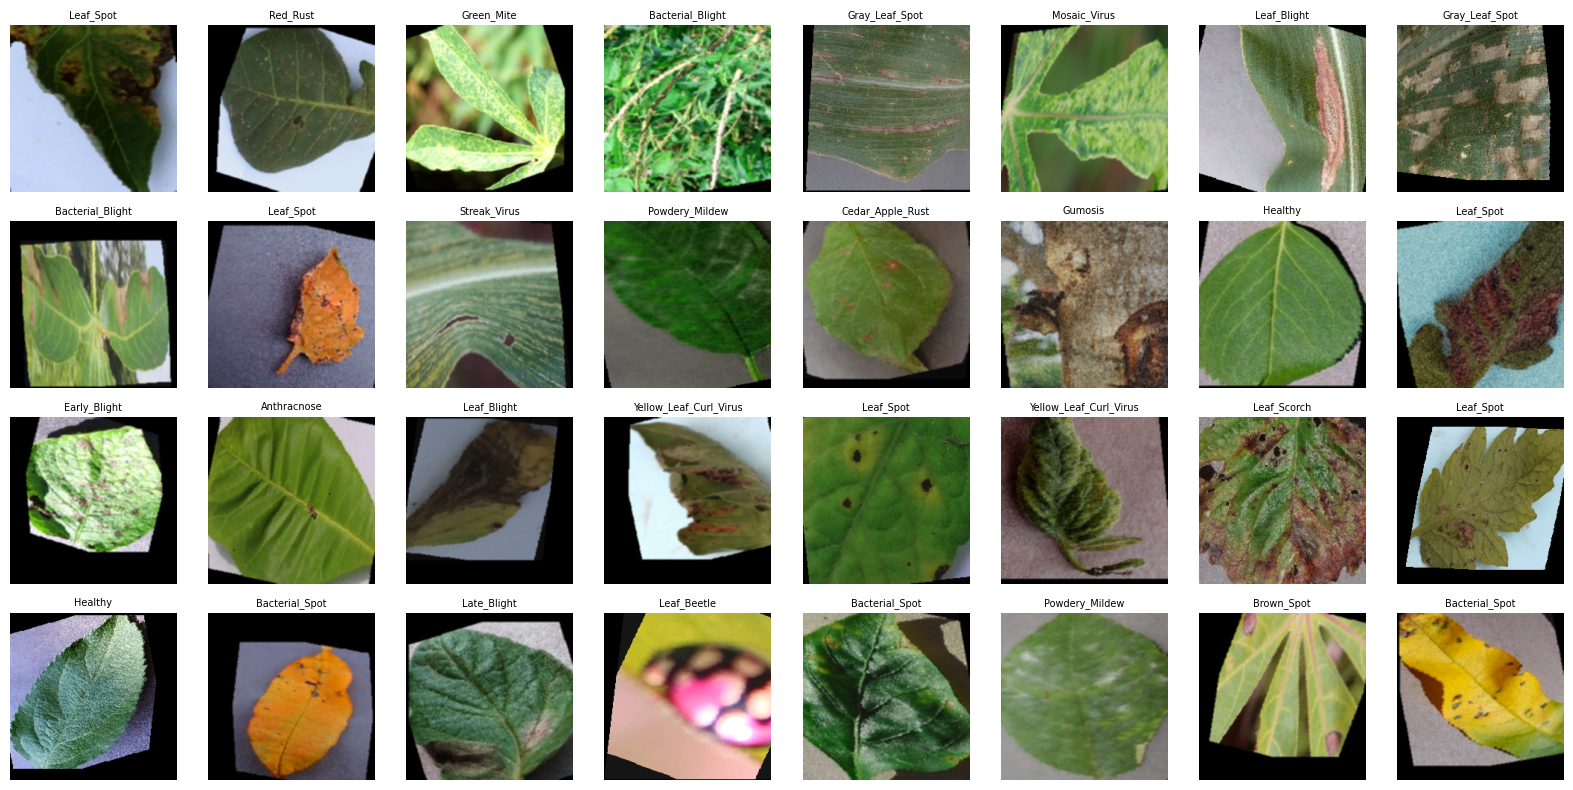

INFO:__main__:Batch visualization saved


In [7]:
import torch
import matplotlib.pyplot as plt

# ── Constants ─────────────────────────────────────────────────────────────────
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denormalize(tensor, mean=MEAN, std=STD):
    return (tensor * std + mean).clamp(0, 1)

# ── Fast single-batch loader (no worker spawn, no sampler overhead) ───────────
_viz_loader = torch.utils.data.DataLoader(
    train_loader.dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,       # avoids subprocess spawn — the main bottleneck
    pin_memory=False,
)
batch_images, batch_labels = next(iter(_viz_loader))

print(f"Batch shape : {batch_images.shape}")
print(f"Labels      : {batch_labels[:8].numpy()}")
print(f"dtype       : {batch_images.dtype}")

# ── Precompute all display images at once ─────────────────────────────────────
imgs        = denormalize(batch_images[:32])          # (32, 3, H, W)
imgs_np     = imgs.permute(0, 2, 3, 1).numpy()        # (32, H, W, 3) — one transpose
short_names = [
    train_loader.dataset.idx_to_class[batch_labels[i].item()].split("___")[-1]
    for i in range(len(imgs_np))
]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for ax, img, name in zip(axes.flat, imgs_np, short_names):
    ax.imshow(img)
    ax.set_title(name, fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../notebooks/figures/11_batch_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
logger.info('Batch visualization saved')

## 7. DataLoader Performance Profiling

In [ ]:
print("\n=== DATALOADER PERFORMANCE PROFILING ===")

# Profile training loader
times = []
for i, (images, labels) in enumerate(train_loader):
    start = time.time()
    # Simulate moving to GPU
    if torch.cuda.is_available():
        images = images.to(device)
        labels = labels.to(device)
    times.append(time.time() - start)
    
    if i >= 10:  # Profile first 10 batches
        break

if times:
    avg_time = np.mean(times)
    print(f"\nAverage batch load time: {avg_time*1000:.2f} ms")
    print(f"Throughput: {BATCH_SIZE/avg_time:.1f} images/sec")
    print(f"Epoch time (estimate): {len(train_loader)*avg_time/60:.1f} minutes")


=== DATALOADER PERFORMANCE PROFILING ===


## 8. Training Loop Template

In [ ]:
print("\n" + "="*70)
print("TRAINING LOOP TEMPLATE")
print("="*70)

template = """
import torch
import torch.nn as nn
from torch.optim import Adam

# Initialize model
model = YourModel(num_classes=57).to(device)

# Loss function with class weights
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Optimizer
optimizer = Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

# Training loop
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)  # Weighted loss
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
        if batch_idx % 50 == 0:
            print(f'Epoch [{epoch+1}], Batch [{batch_idx}], Loss: {loss:.4f}')
    
    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    
    scheduler.step()
    print(f'Epoch {epoch+1}: Train Loss={train_loss/len(train_loader):.4f}, Val Loss={val_loss/len(val_loader):.4f}')
"""

print(template)

## 9. Summary & Best Practices

In [ ]:
print("\n" + "="*70)
print("DATA PIPELINE BEST PRACTICES")
print("="*70)

print("""
## Pipeline Components:

1. DATASET CLASS (CropDiseaseDataset)
   ✓ Handles file I/O with error handling
   ✓ Applies transforms on-the-fly
   ✓ Supports all splits (train/val/test)
   ✓ Lazy loading (memory efficient)

2. AUGMENTATION (get_train_transforms)
   ✓ Strong augmentation: rotation, color jitter, affine
   ✓ Geometric: horizontal/vertical flips
   ✓ Normalization: ImageNet stats
   ✓ Applied stochastically per image

3. WEIGHTED SAMPLING
   ✓ Balanced class representation
   ✓ Smoothed (√ inverse) to avoid noise
   ✓ Replacement=True for diversity

4. DATALOADER CONFIGURATION
   ✓ Batch size: 32 (balance memory/convergence)
   ✓ Workers: 4 (parallel I/O)
   ✓ Pin memory: True (if GPU)
   ✓ Drop last: True (batch normalization stability)

## Performance Optimization:
   • Prefetch batches: Set num_workers > 0
   • Pin GPU memory: Set pin_memory=True
   • Use CenterCrop: Consistent input size
   • LANCZOS interpolation: Higher quality resizing
   • Normalized tensors: Faster convergence

## Debugging Tips:
   • Enable drop_last=False to process all samples
   • Set num_workers=0 to identify I/O issues
   • Log batch statistics: shape, dtype, range
   • Visualize augmented batches before training
   • Monitor GPU memory: profile peak usage

## Expected Results:
   • Batch load time: 50-100ms per 32 images
   • GPU throughput: 300-500 images/sec
   • Epoch time: 10-15 minutes (57 classes, ~175k samples)
""")

print("\n" + "="*70)
print("YOUR PIPELINE IS READY FOR DEFENSE!")
print("="*70)